In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('HousePricePrediction.csv')

In [3]:
df.shape

(2919, 13)

In [4]:
df.head(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   str    
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   str    
 5   BldgType      2919 non-null   str    
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   str    
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), str(4)
memory usage: 352.3 KB


In [7]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [9]:
df = df.dropna()

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")


Numeric Columns: ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']
Categorical Columns: ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


C:\Users\computer lab\AppData\Local\Temp\ipykernel_3836\155426342.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [12]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"\nDataset shape after encoding: {df_encoded.shape}")
print(f"\nProcessed Dataset Info:")
print(df_encoded.info())


Dataset shape after encoding: (1460, 35)

Processed Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   1460 non-null   int64  
 1   MSSubClass           1460 non-null   int64  
 2   LotArea              1460 non-null   int64  
 3   OverallCond          1460 non-null   int64  
 4   YearBuilt            1460 non-null   int64  
 5   YearRemodAdd         1460 non-null   int64  
 6   BsmtFinSF2           1460 non-null   float64
 7   TotalBsmtSF          1460 non-null   float64
 8   SalePrice            1460 non-null   float64
 9   MSZoning_FV          1460 non-null   bool   
 10  MSZoning_RH          1460 non-null   bool   
 11  MSZoning_RL          1460 non-null   bool   
 12  MSZoning_RM          1460 non-null   bool   
 13  LotConfig_CulDSac    1460 non-null   bool   
 14  LotConfig_FR2        1460 non-nu

In [13]:
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']


print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")


Features (X) shape: (1460, 34)
Target (y) shape: (1460,)

Feature columns: ['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm', 'Exterior1st_BrkFace', 'Exterior1st_CBlock', 'Exterior1st_CemntBd', 'Exterior1st_HdBoard', 'Exterior1st_ImStucc', 'Exterior1st_MetalSd', 'Exterior1st_Plywood', 'Exterior1st_Stone', 'Exterior1st_Stucco', 'Exterior1st_VinylSd', 'Exterior1st_Wd Sdng', 'Exterior1st_WdShing']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining Features (X_train) shape: {X_train.shape}")
print(f"Testing Features (X_test) shape: {X_test.shape}")
print(f"Training Target (y_train) shape: {y_train.shape}")
print(f"Testing Target (y_test) shape: {y_test.shape}")


Training set size: 1168 samples (80.0%)
Testing set size: 292 samples (20.0%)

Training Features (X_train) shape: (1168, 34)
Testing Features (X_test) shape: (292, 34)
Training Target (y_train) shape: (1168,)
Testing Target (y_test) shape: (292,)


In [15]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print(f"\nModel Intercept: {model.intercept_:.2f}")
print(f"\nModel Coefficients (top 10):")
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients_df.head(10))


Model Intercept: -2942537.94

Model Coefficients (top 10):
                Feature    Coefficient
18       BldgType_Twnhs -128856.676297
16      BldgType_2fmCon -122694.217843
19      BldgType_TwnhsE -108376.463020
17      BldgType_Duplex  -71958.839944
29    Exterior1st_Stone   57959.057497
20  Exterior1st_AsphShn   50061.406609
22  Exterior1st_BrkFace   38357.800970
9           MSZoning_RH   31705.788697
8           MSZoning_FV   28406.959574
10          MSZoning_RL   27182.109589


In [17]:

y_pred = model.predict(X_test)

In [18]:
print(f"\nActual vs Predicted (First 10 samples):")
comparison_df = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10],
    'Difference': y_test.values[:10] - y_pred[:10]
})
print(comparison_df)


Actual vs Predicted (First 10 samples):
   Actual Price  Predicted Price     Difference
0      154500.0    168733.001891  -14233.001891
1      325000.0    243223.761211   81776.238789
2      115000.0    114785.412278     214.587722
3      159000.0    157880.219083    1119.780917
4      315500.0    254517.600860   60982.399140
5       75500.0    156703.578885  -81203.578885
6      311500.0    178379.561667  133120.438333
7      146000.0    127064.111212   18935.888788
8       84500.0    133197.418859  -48697.418859
9      135500.0    149331.190822  -13831.190822


In [19]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


In [20]:
print(f"Mean Absolute Error (MAE):        ${mae:,.2f}")
print(f"Mean Squared Error (MSE):         ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE):   ${rmse:,.2f}")
print(f"R² Score:                         {r2:.4f}")

Mean Absolute Error (MAE):        $34,129.49
Mean Squared Error (MSE):         $2,917,494,855.29
Root Mean Squared Error (RMSE):   $54,013.84
R² Score:                         0.6196


In [21]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print(f"\nTraining R² Score:                {train_r2:.4f}")
print(f"Testing R² Score:                 {test_r2:.4f}")


Training R² Score:                0.6143
Testing R² Score:                 0.6196


In [1]:

1. MEAN ABSOLUTE ERROR (MAE):
   - Value: ${mae:,.2f}
   - Interpretation: On average, the model's predictions are off by 
     ${mae:,.2f}. Lower values indicate better accuracy.

2. MEAN SQUARED ERROR (MSE):
   - Value: ${mse:,.2f}
   - Interpretation: Average of squared differences between actual and 
     predicted values. Penalizes larger errors more heavily.

3. ROOT MEAN SQUARED ERROR (RMSE):
   - Value: ${rmse:,.2f}
   - Interpretation: Square root of MSE, in the same unit as the target 
     variable (price). Model predictions deviate by ~${rmse:,.2f} on average.

4. R² SCORE:
   - Value: {r2:.4f}
   - Interpretation: The model explains {r2*100:.2f}% of the variance in house prices.
   - Scale: 0 to 1 (higher is better)

5. OVERFITTING/UNDERFITTING CHECK:
   - Training R²: {train_r2:.4f}
   - Testing R²: {test_r2:.4f}
   - Difference: {abs(train_r2 - test_r2):.4f}
   
   {"⚠️ SLIGHT OVERFITTING DETECTED" if train_r2 - test_r2 > 0.05 else "✓ Good generalization"}
   (Training performs {'better' if train_r2 > test_r2 else 'similarly'} than testing)

6. OVERALL MODEL ASSESSMENT:
""")

if r2 > 0.8:
    assessment = "EXCELLENT - The model performs very well and explains >80% of variance"
elif r2 > 0.6:
    assessment = "GOOD - The model performs reasonably well and explains 60-80% of variance"
elif r2 > 0.4:
    assessment = "ACCEPTABLE - The model has moderate performance"
else:
    assessment = "POOR - The model needs significant improvement"

print(f"   Status: {assessment}")

print(f"""
7. RECOMMENDATIONS:
""")

if r2 < 0.7:
    print(f"""   - Consider adding more relevant features
   - Try polynomial regression or other advanced models
   - Check for outliers in the data
   - Perform feature engineering (create new features)
   - Explore non-linear relationships
""")
else:
    print(f"""   - Model performance is satisfactory
   - The model can be used for predictions with reasonable confidence
   - Monitor performance on new data
""")


SyntaxError: invalid decimal literal (997836821.py, line 2)

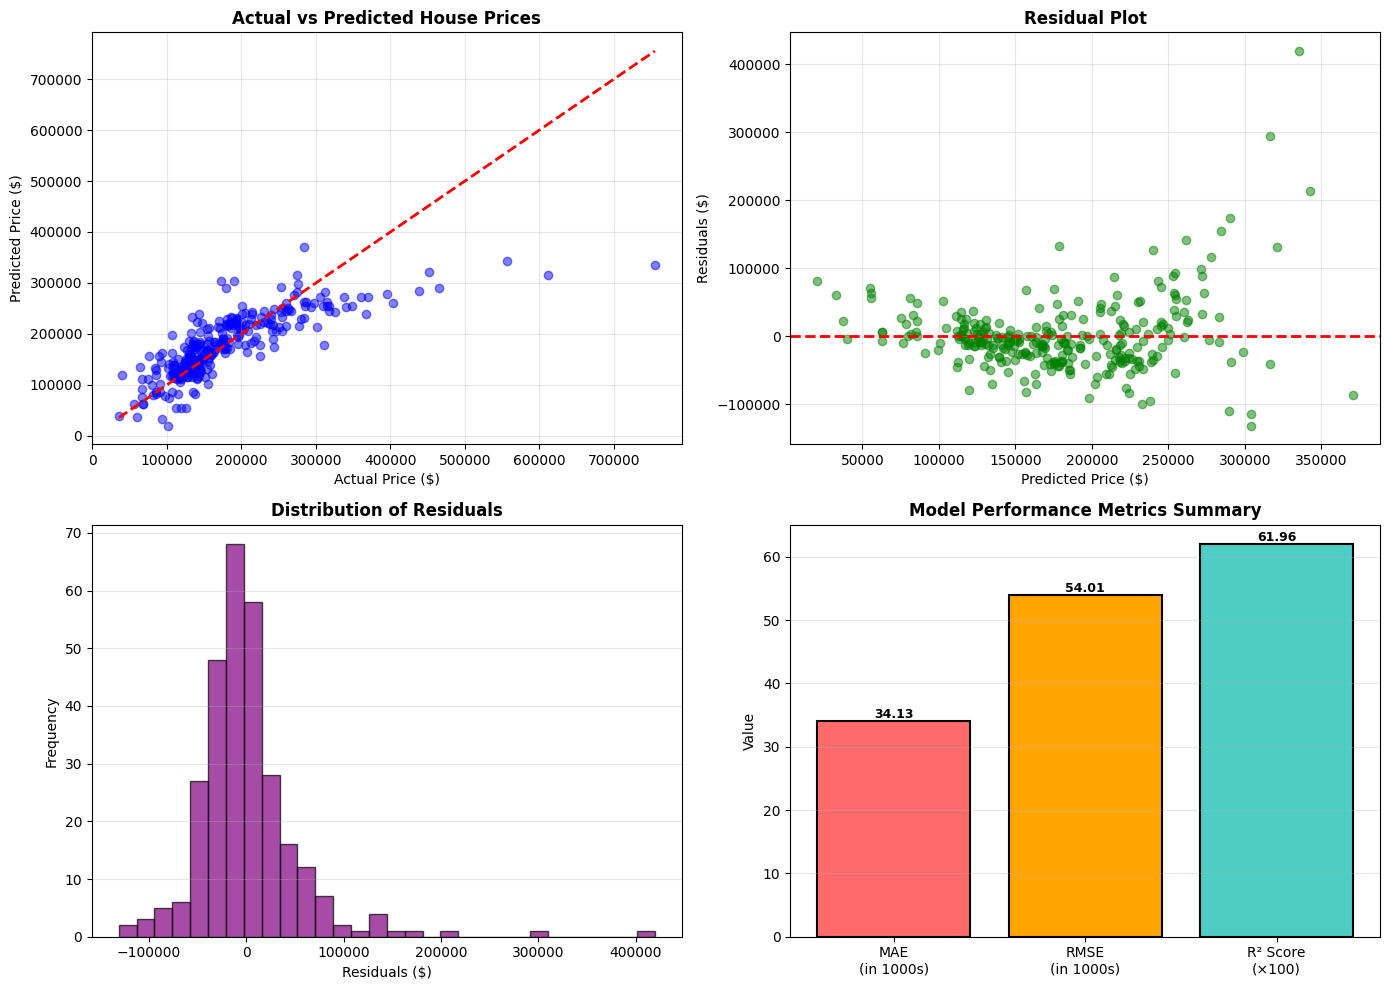

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=10)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=10)
axes[0, 0].set_title('Actual vs Predicted House Prices', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=10)
axes[0, 1].set_ylabel('Residuals ($)', fontsize=10)
axes[0, 1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Distribution of Residuals
axes[1, 0].hist(residuals, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals ($)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Metrics Summary
metrics_labels = ['MAE\n(in 1000s)', 'RMSE\n(in 1000s)', 'R² Score\n(×100)']
metrics_values = [mae/1000, rmse/1000, r2*100]
colors_bar = ['#FF6B6B', '#FFA500', '#4ECDC4']
bars = axes[1, 1].bar(metrics_labels, metrics_values, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[1, 1].set_ylabel('Value', fontsize=10)
axes[1, 1].set_title('Model Performance Metrics Summary', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Model_Performance_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()
